In [ ]:
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix , accuracy_score , classification_report

In [ ]:
x,y= load_breast_cancer(as_frame=True,return_X_y=True)
print(x.head())
print(y.value_counts())

   mean radius  mean texture  ...  worst symmetry  worst fractal dimension
0        17.99         10.38  ...          0.4601                  0.11890
1        20.57         17.77  ...          0.2750                  0.08902
2        19.69         21.25  ...          0.3613                  0.08758
3        11.42         20.38  ...          0.6638                  0.17300
4        20.29         14.34  ...          0.2364                  0.07678

[5 rows x 30 columns]
target
1    357
0    212
Name: count, dtype: int64


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

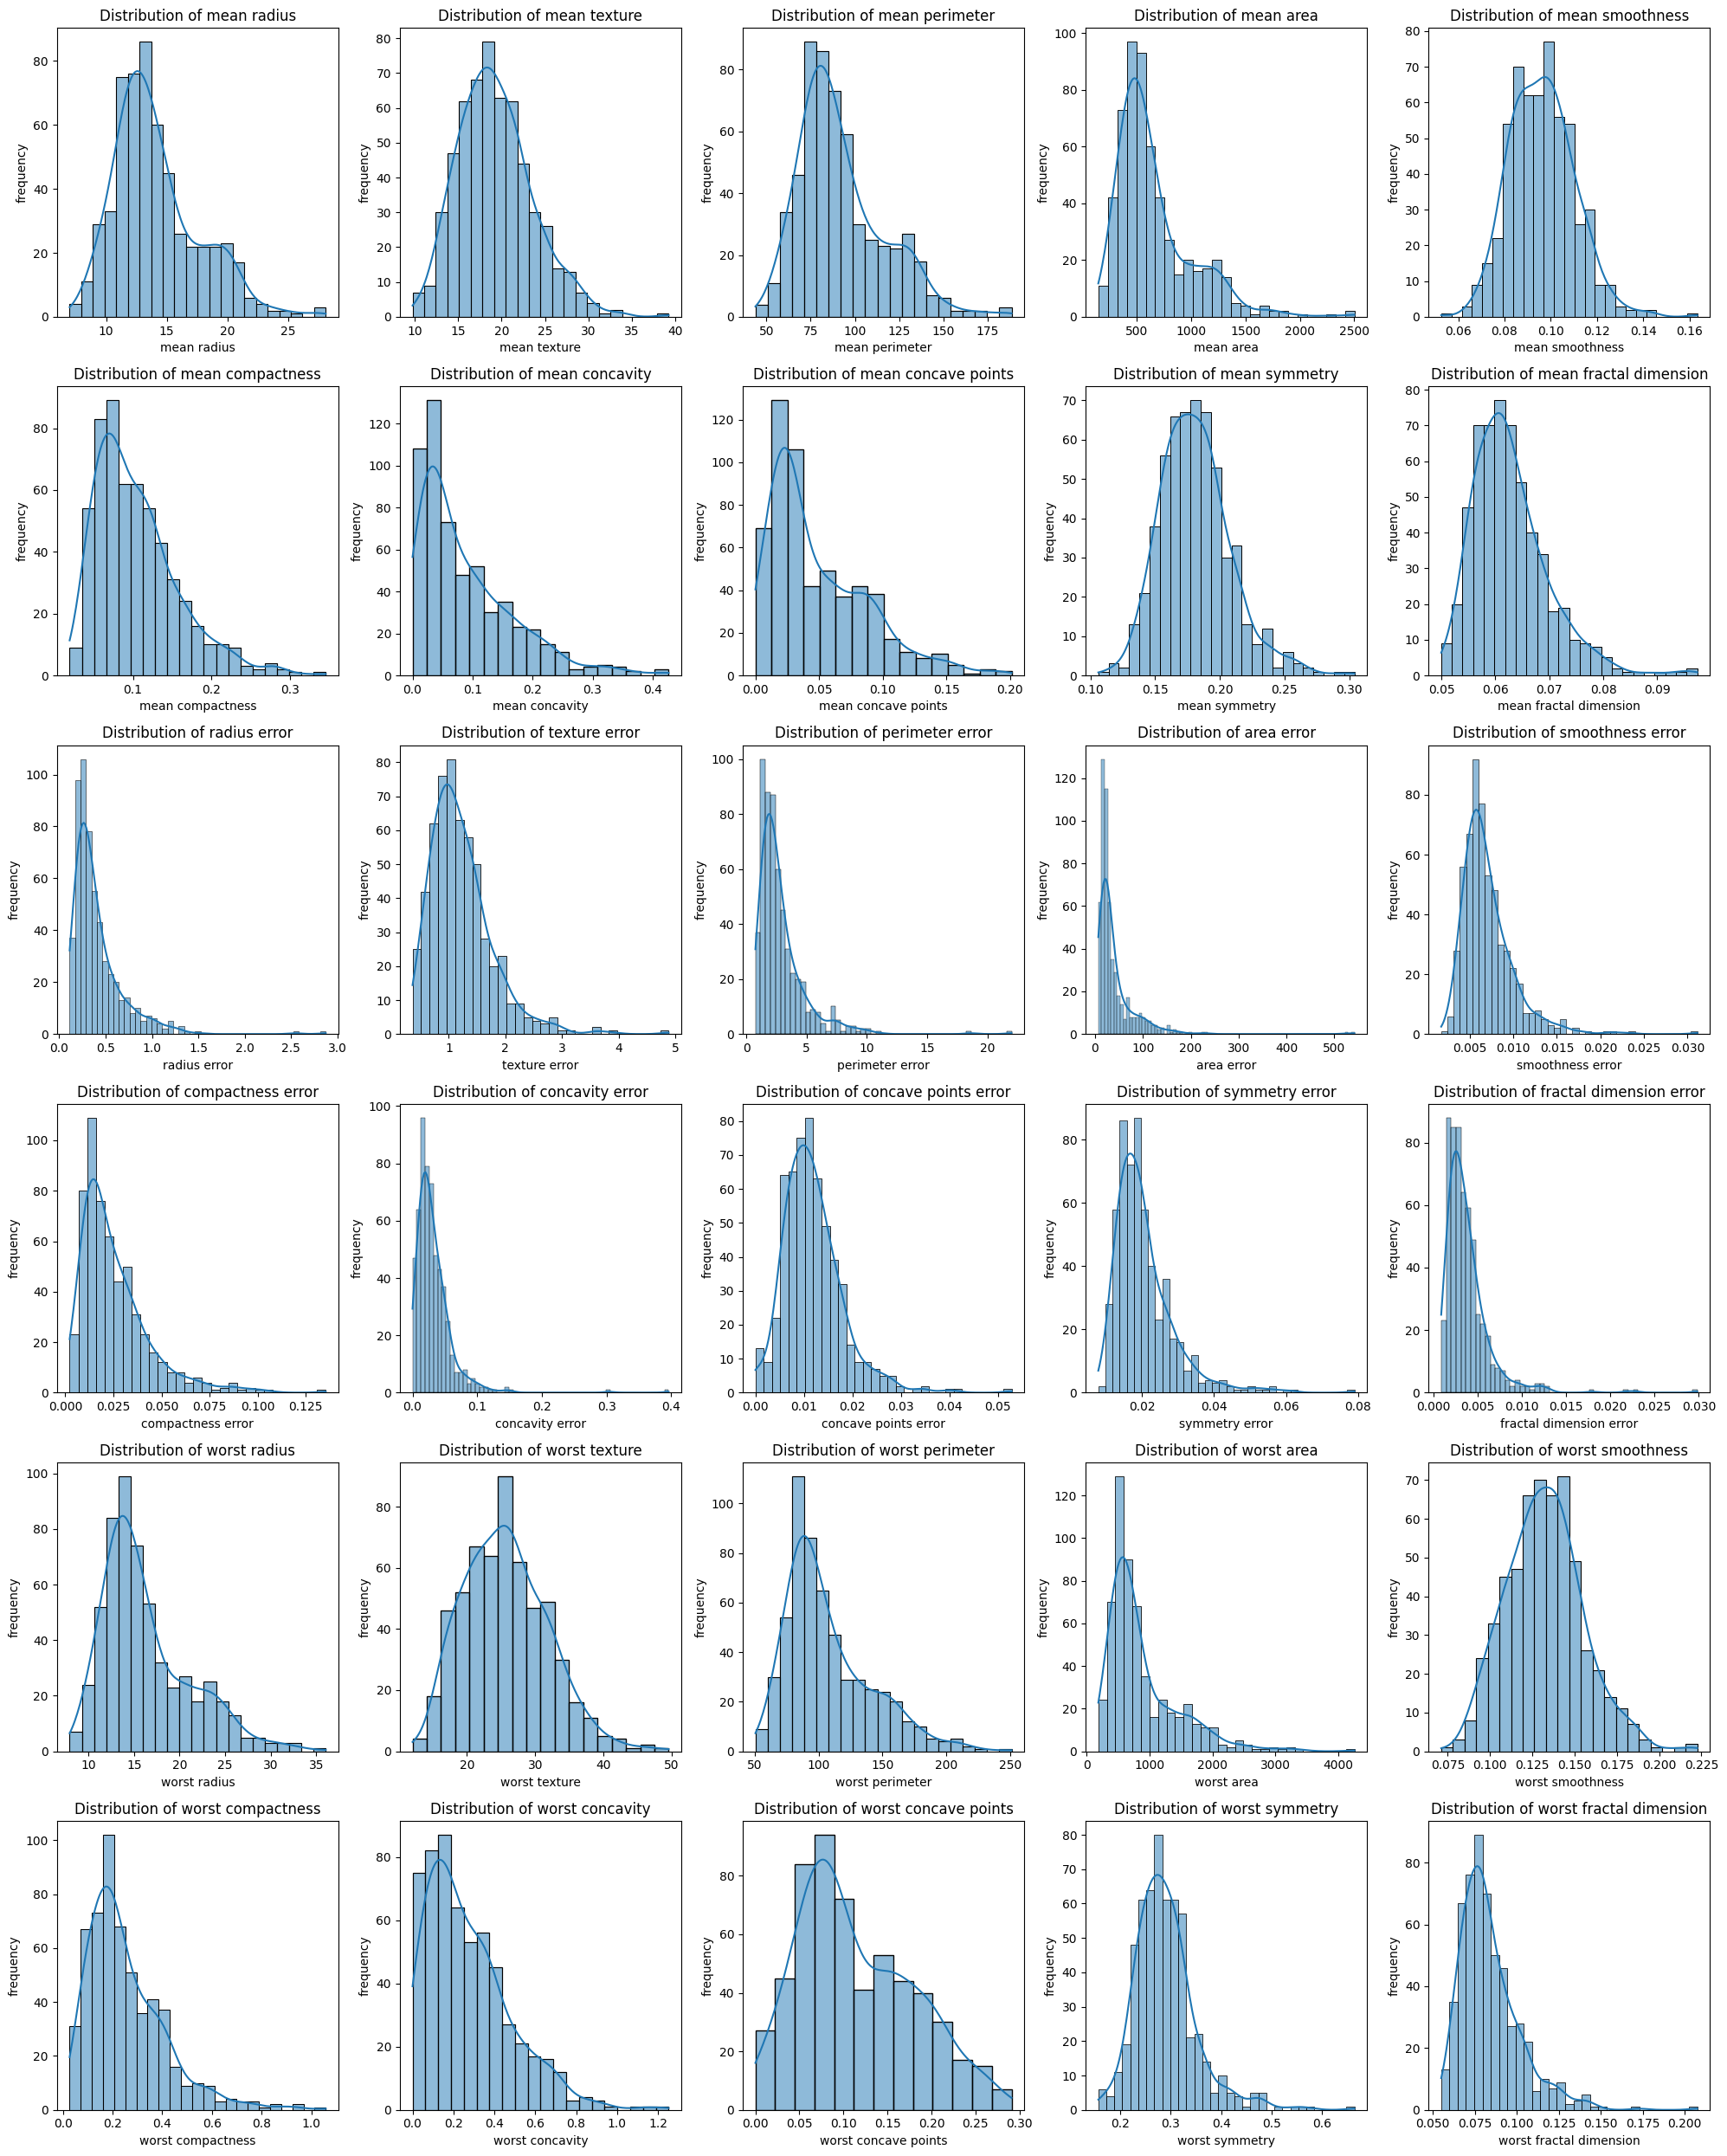

In [ ]:
plt.figure(figsize=(20, 25))
for i, column in enumerate(x.columns):
    plt.subplot(6, 5, i + 1)
    sns.histplot(x[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('frequency')
plt.tight_layout()
plt.show()

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=5)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred_test = log_reg.predict(x_test)
y_pred_train = log_reg.predict(x_train)

In [ ]:
print(confusion_matrix(y_test,y_pred_test))
print(accuracy_score(y_test,y_pred_test))
print(classification_report(y_test,y_pred_test))
print("-------------------------------------")
print(confusion_matrix(y_train,y_pred_train))
print(accuracy_score(y_train,y_pred_train))
print(classification_report(y_train,y_pred_train))

[[46  2]
 [ 1 65]]
0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        48
           1       0.97      0.98      0.98        66

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

-------------------------------------
[[161   3]
 [  1 290]]
0.9912087912087912
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       164
           1       0.99      1.00      0.99       291

    accuracy                           0.99       455
   macro avg       0.99      0.99      0.99       455
weighted avg       0.99      0.99      0.99       455



<Axes: >

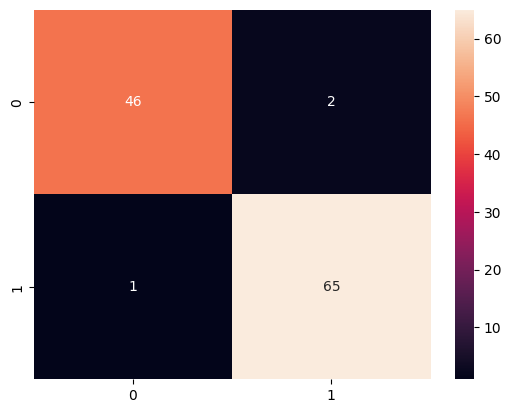

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred_test),annot=True)